<a href="https://colab.research.google.com/github/guhmtzz/CIAO_GUSTAVO_2026/blob/main/Aula_4_exerc%C3%ADcio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


RESULTADOS — ALGORITMO GENÉTICO
Melhor rota encontrada: [0 4 1 6 9 7 2 8 3 5]
Custo base da rota: 290.31
Penalidade: 0.00
Fitness final: 290.31
Tempo de execução: 2712.64 ms


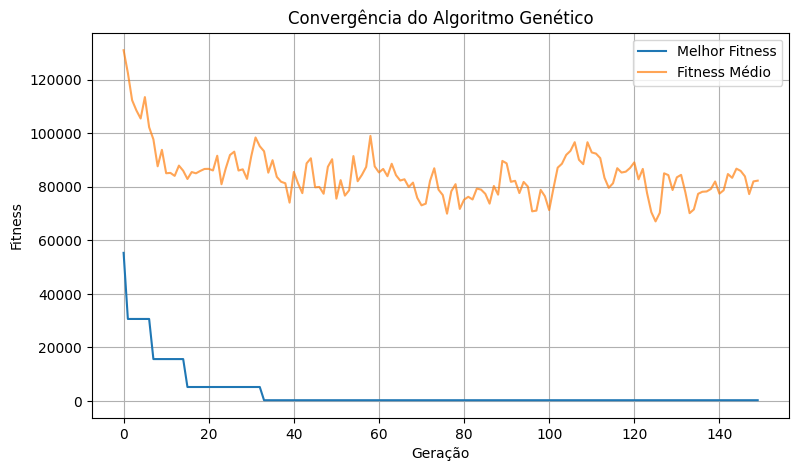

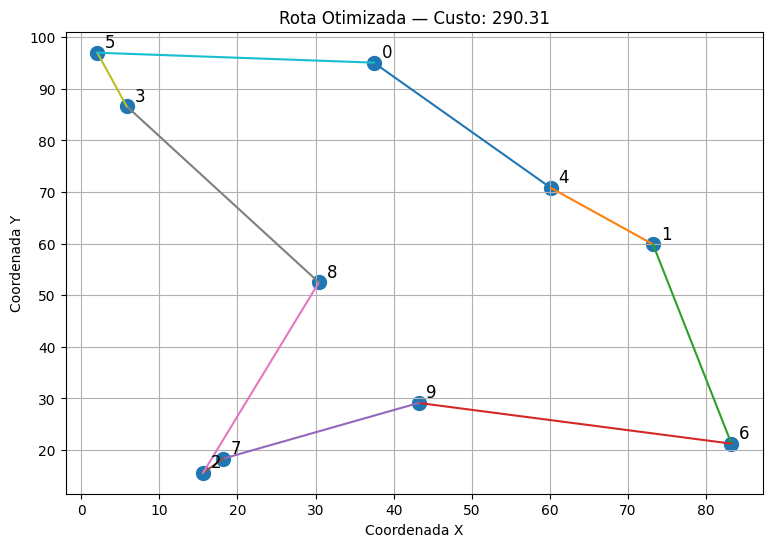

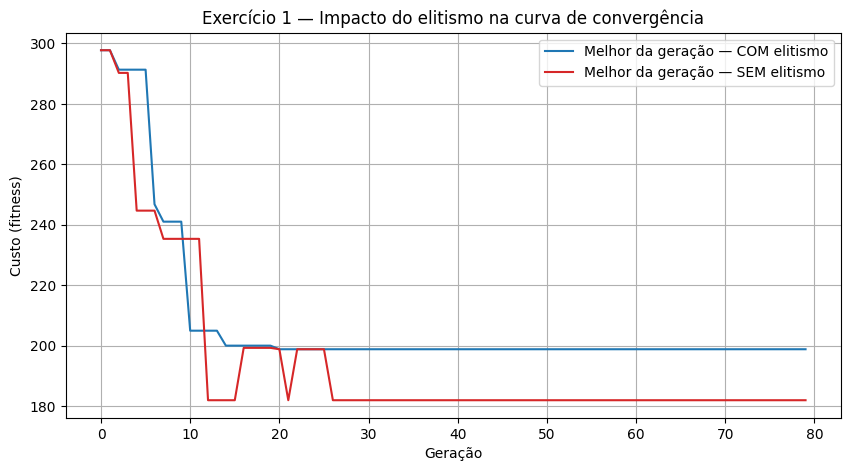

Regressões (piora de geração p/ geração) — COM elitismo: 0
Regressões (piora de geração p/ geração) — SEM elitismo: 2

Em 30 execuções independentes de 80 gerações cada:
COM elitismo -> média de regressões por execução: 0.00 | custo final médio: 220.93 (desvio padrão: 37.60)
SEM elitismo -> média de regressões por execução: 1.53 | custo final médio: 234.13 (desvio padrão: 36.40)


In [1]:
# ============================================================
# AULA 04 — ALGORITMOS GENÉTICOS EM PROBLEMAS COMBINATÓRIOS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. CONFIGURAÇÕES DO PROBLEMA
# ============================================================

np.random.seed(42)

NUM_NOS = 10
TAMANHO_POPULACAO = 60
NUM_GERACOES = 150

TAXA_MUTACAO = 0.20

# Restrição simulada: nenhum enlace deve possuir distância superior a este valor
LIMITE_ENLACE = 50.0

# Penalização aplicada para cada violação
PENALIDADE = 1000.0


# ============================================================
# 2. GERAÇÃO DOS NÓS
# ============================================================

posicoes_nos = np.random.uniform(0, 100, size=(NUM_NOS, 2))


# ============================================================
# 3. MATRIZ DE DISTÂNCIAS
# ============================================================

def gerar_matriz_distancias(posicoes):
    """Calcula a distância euclidiana entre todos os pares de nós."""
    num_nos = len(posicoes)
    matriz = np.zeros((num_nos, num_nos))
    for i in range(num_nos):
        for j in range(num_nos):
            diferenca = posicoes[i] - posicoes[j]
            matriz[i, j] = np.linalg.norm(diferenca)
    return matriz


matriz_distancias = gerar_matriz_distancias(posicoes_nos)


# ============================================================
# 4. FUNÇÃO DE CUSTO DA ROTA
# ============================================================

def calcular_custo_rota(rota, matriz):
    """
    Calcula o custo total de uma rota fechada.
    Exemplo: [0, 3, 1, 5] representa 0 → 3 → 1 → 5 → 0
    """
    custo = 0.0
    for i in range(len(rota)):
        origem = rota[i]
        destino = rota[(i + 1) % len(rota)]
        custo += matriz[origem, destino]
    return custo


# ============================================================
# 5. FUNÇÃO DE PENALIZAÇÃO
# ============================================================

def calcular_penalidade(rota, matriz, limite_enlace, penalidade):
    """Aplica penalização quando algum enlace da rota ultrapassa o limite permitido."""
    total_penalidade = 0.0
    for i in range(len(rota)):
        origem = rota[i]
        destino = rota[(i + 1) % len(rota)]
        distancia = matriz[origem, destino]
        if distancia > limite_enlace:
            violacao = distancia - limite_enlace
            total_penalidade += penalidade * violacao
    return total_penalidade


# ============================================================
# 6. FUNÇÃO FITNESS
# ============================================================

def calcular_fitness(rota, matriz, limite_enlace, penalidade):
    """Fitness = Custo Base + Penalizações (quanto menor, melhor)."""
    custo_base = calcular_custo_rota(rota, matriz)
    multa = calcular_penalidade(rota, matriz, limite_enlace, penalidade)
    fitness = custo_base + multa
    return fitness


# ============================================================
# 7. CROSSOVER OX
# ============================================================

def crossover_ox(pai1, pai2):
    """Ordered Crossover (OX). Preserva a validade da permutação."""
    tamanho = len(pai1)
    filho = np.full(tamanho, -1, dtype=int)

    ponto1, ponto2 = sorted(np.random.choice(tamanho, 2, replace=False))

    filho[ponto1:ponto2] = pai1[ponto1:ponto2]

    posicao = ponto2

    for elemento in pai2:
        if elemento not in filho:
            if posicao >= tamanho:
                posicao = 0
            filho[posicao] = elemento
            posicao += 1

    return filho


# ============================================================
# 8. MUTAÇÃO SWAP
# ============================================================

def mutacao_swap(rota, taxa_mutacao):
    """Troca aleatoriamente duas posições da rota."""
    rota = rota.copy()
    if np.random.rand() < taxa_mutacao:
        idx1, idx2 = np.random.choice(len(rota), 2, replace=False)
        rota[idx1], rota[idx2] = rota[idx2], rota[idx1]
    return rota


# ============================================================
# 9. SELEÇÃO POR TORNEIO
# ============================================================

def selecao_torneio(populacao, fitness, tamanho_torneio=2):
    """Seleciona um indivíduo através de um torneio (menor fitness = vencedor)."""
    participantes = np.random.choice(len(populacao), tamanho_torneio, replace=False)
    melhor = participantes[np.argmin([fitness[i] for i in participantes])]
    return populacao[melhor]


# ============================================================
# 10. CRIAÇÃO DA POPULAÇÃO INICIAL
# ============================================================

def criar_populacao(tamanho_populacao, num_nos):
    return [np.random.permutation(num_nos) for _ in range(tamanho_populacao)]


populacao = criar_populacao(TAMANHO_POPULACAO, NUM_NOS)


# ============================================================
# 11. HISTÓRICO DA EVOLUÇÃO
# ============================================================

historico_melhor = []
historico_medio = []

melhor_rota_global = None
melhor_fitness_global = np.inf


# ============================================================
# 12. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

tempo_inicio = time.time()

for geracao in range(NUM_GERACOES):

    # Avaliação da população
    fitness_populacao = [
        calcular_fitness(individuo, matriz_distancias, LIMITE_ENLACE, PENALIDADE)
        for individuo in populacao
    ]

    # Melhor indivíduo da geração
    indice_melhor = np.argmin(fitness_populacao)
    melhor_rota_geracao = populacao[indice_melhor].copy()
    melhor_fitness_geracao = fitness_populacao[indice_melhor]

    # Atualização do melhor indivíduo global
    if melhor_fitness_geracao < melhor_fitness_global:
        melhor_fitness_global = melhor_fitness_geracao
        melhor_rota_global = melhor_rota_geracao.copy()

    # Histórico
    historico_melhor.append(melhor_fitness_global)
    historico_medio.append(np.mean(fitness_populacao))

    # Elitismo
    nova_populacao = [melhor_rota_global.copy()]

    # Reprodução
    while len(nova_populacao) < TAMANHO_POPULACAO:
        pai1 = selecao_torneio(populacao, fitness_populacao)
        pai2 = selecao_torneio(populacao, fitness_populacao)
        filho = crossover_ox(pai1, pai2)
        filho = mutacao_swap(filho, TAXA_MUTACAO)
        nova_populacao.append(filho)

    populacao = nova_populacao

tempo_fim = time.time()


# ============================================================
# 13. AVALIAÇÃO DA SOLUÇÃO FINAL
# ============================================================

custo_final = calcular_custo_rota(melhor_rota_global, matriz_distancias)
penalidade_final = calcular_penalidade(melhor_rota_global, matriz_distancias, LIMITE_ENLACE, PENALIDADE)
fitness_final = custo_final + penalidade_final
tempo_execucao = (tempo_fim - tempo_inicio) * 1000


# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS — ALGORITMO GENÉTICO")
print("=" * 60)
print(f"Melhor rota encontrada: {melhor_rota_global}")
print(f"Custo base da rota: {custo_final:.2f}")
print(f"Penalidade: {penalidade_final:.2f}")
print(f"Fitness final: {fitness_final:.2f}")
print(f"Tempo de execução: {tempo_execucao:.2f} ms")
print("=" * 60)


# ============================================================
# 15. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(historico_melhor, label="Melhor Fitness")
plt.plot(historico_medio, label="Fitness Médio", alpha=0.7)
plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 16. VISUALIZAÇÃO DA ROTA
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(posicoes_nos[:, 0], posicoes_nos[:, 1], s=100)

for i, (x, y) in enumerate(posicoes_nos):
    plt.text(x + 1, y + 1, str(i), fontsize=12)

for i in range(NUM_NOS):
    origem = melhor_rota_global[i]
    destino = melhor_rota_global[(i + 1) % NUM_NOS]
    plt.plot(
        [posicoes_nos[origem, 0], posicoes_nos[destino, 0]],
        [posicoes_nos[origem, 1], posicoes_nos[destino, 1]]
    )

plt.title(f"Rota Otimizada — Custo: {custo_final:.2f}")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.grid(True)
plt.show()


# ============================================================
# EXERCÍCIO 1: ANÁLISE DO ELITISMO NA ESTABILIDADE ALGORÍTMICA
# ============================================================

def calcular_custo(rota, matriz):
    dist = 0
    for i in range(len(rota) - 1):
        dist += matriz[rota[i], rota[i + 1]]
    return dist + matriz[rota[-1], rota[0]]


def rodar_exercicio1(usar_elitismo, seed):
    np.random.seed(seed)
    NUM_NOS_EX = 8
    matriz_teste = np.random.uniform(10, 100, (NUM_NOS_EX, NUM_NOS_EX))
    TAM_POP = 40
    GERACOES_EX = 80

    populacao_ex = [np.random.permutation(NUM_NOS_EX) for _ in range(TAM_POP)]

    melhor_da_geracao = []  # menor custo DENTRO da população atual (pode piorar)
    melhor_ja_visto = []    # melhor custo encontrado até agora
    melhor_global = np.inf

    for g in range(GERACOES_EX):
        custos = [calcular_custo(ind, matriz_teste) for ind in populacao_ex]
        melhor_idx = np.argmin(custos)
        custo_pop = custos[melhor_idx]

        melhor_da_geracao.append(custo_pop)
        melhor_global = min(melhor_global, custo_pop)
        melhor_ja_visto.append(melhor_global)

        novos = []
        if usar_elitismo:
            novos.append(populacao_ex[melhor_idx].copy())

        while len(novos) < TAM_POP:
            i1, i2 = np.random.choice(TAM_POP, 2, replace=False)
            pai = populacao_ex[i1] if custos[i1] < custos[i2] else populacao_ex[i2]

            filho = pai.copy()
            if np.random.rand() < 0.3:
                idx1, idx2 = np.random.choice(NUM_NOS_EX, 2, replace=False)
                filho[idx1], filho[idx2] = filho[idx2], filho[idx1]
            novos.append(filho)

        populacao_ex = novos

    return melhor_da_geracao, melhor_ja_visto


# --- (a) Uma execução única, para visualizar a curva de convergência ---
mg_com, mv_com = rodar_exercicio1(True, seed=42)
mg_sem, mv_sem = rodar_exercicio1(False, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(mg_com, label="Melhor da geração — COM elitismo", color="tab:blue")
plt.plot(mg_sem, label="Melhor da geração — SEM elitismo", color="tab:red")
plt.title("Exercício 1 — Impacto do elitismo na curva de convergência")
plt.xlabel("Geração")
plt.ylabel("Custo (fitness)")
plt.grid(True)
plt.legend()
plt.show()


# --- (b) Contagem de "regressões" (piora de uma geração para a seguinte) ---
def contar_regressoes(historico):
    return sum(1 for i in range(1, len(historico)) if historico[i] > historico[i - 1] + 1e-9)


print("Regressões (piora de geração p/ geração) — COM elitismo:", contar_regressoes(mg_com))
print("Regressões (piora de geração p/ geração) — SEM elitismo:", contar_regressoes(mg_sem))


# --- (c) Experimento estatístico: repetir com várias sementes independentes ---
trials = 30
regressoes_com, regressoes_sem = [], []
finais_com, finais_sem = [], []

for s in range(trials):
    mg_c, _ = rodar_exercicio1(True, seed=1000 + s)
    mg_s, _ = rodar_exercicio1(False, seed=1000 + s)
    regressoes_com.append(contar_regressoes(mg_c))
    regressoes_sem.append(contar_regressoes(mg_s))
    finais_com.append(mg_c[-1])
    finais_sem.append(mg_s[-1])

print(f"\nEm {trials} execuções independentes de 80 gerações cada:")
print(f"COM elitismo -> média de regressões por execução: {np.mean(regressoes_com):.2f} | "
      f"custo final médio: {np.mean(finais_com):.2f} (desvio padrão: {np.std(finais_com):.2f})")
print(f"SEM elitismo -> média de regressões por execução: {np.mean(regressoes_sem):.2f} | "
      f"custo final médio: {np.mean(finais_sem):.2f} (desvio padrão: {np.std(finais_sem):.2f})")